# A cross-sectional observational study on the impact of cost on cardiac

events in adults using simulated data

Tracy Chidyausiku (Stanford University)

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

here() starts at /Users/tracychidyausiku/Coursework/epi/epi203/EPI203_Assignment4_ReproducibleReport


Attaching package: 'table1'

The following objects are masked from 'package:base':

    units, units<-


Attaching package: 'kableExtra'

The following object is masked from 'package:dplyr':

    group_rows


Attaching package: 'broom.helpers'

The following objects are masked from 'package:gtsummary':

    all_categorical, all_continuous, all_contrasts, all_dichotomous,
    all_interaction, all_intercepts

Loading required package: carData

Attaching package: 'car'

The following object is masked from 'package:dplyr':

    recode

The following object is masked from 'package:purrr':

    some

Linking to ImageMagick 6.9.13.29
Enabled features: cairo, fontconfig, freetype, heic, lcms, pango, raw, rsvg, webp
Disabled features: fftw, ghostscript, x11

## Introduction

In the United States, the overwhelming majority of adults experiencing cardiac events fall disproportionately on individuals experiencing poverty (low to very low income) on the county and federal levels. Cardiac events are closely linked with ongoing cardiovascular diseases in patients and are the leading cause of death in the United States. As a result, rates in cardiovascular disease and death in low to very low income individuals have increased at an alarming rate in recent years and are only expected to more than triple in the next five years. To better understand the social mechanisms, primarily financial factors like medical costs, that impact an individual’s ability to prevent or delay cardiac events we used synthetic data to measure how cost influences cardiac events.

The study objective is to measure how cost of care influences cardiac events in the presence of controlling for biological and social factors including age, sex, and smoking. We hypothesize that higher medical costs are associated with an increase in cardiac events when controlling for age, sex, and smoking.

## Methods

A cross-sectional study using synthetic data from the Department of Health Policy at Stanford University was conducted to investigate how medical costs impact cardiac events in adult patients.

### Dataset

Data was used from a synthetic data set created by the Health Policy Department at Stanford University (Sherri Rose, PhD). The data are synthetic and developed in 2026 trained using de-identified health data from a national dataset of adult (18 years and older) cardiac hospitalizations in the United States from 2025. The synthetic dataset is publicly accessible (<https://github.com/MethodsForReproducibleHealthResearch/Assignment2>). The dataset contains 5,000 synthetic adult health records with variables including medical costs, cardiac events, sex, age, and smoking status.

Rows: 5000 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (5): smoke, female, age, cardiac, cost

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

[1] 0

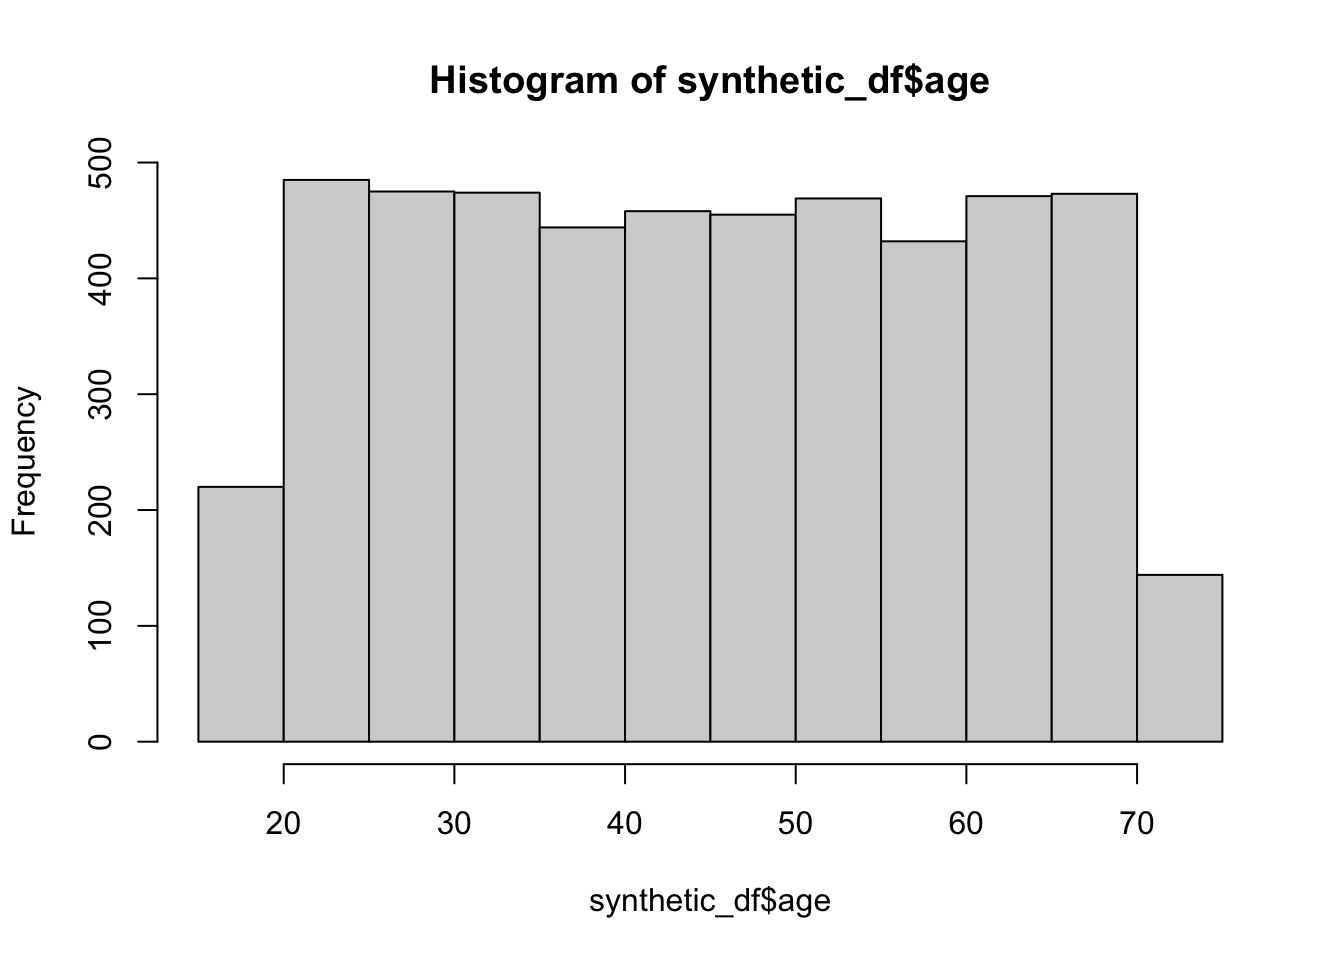

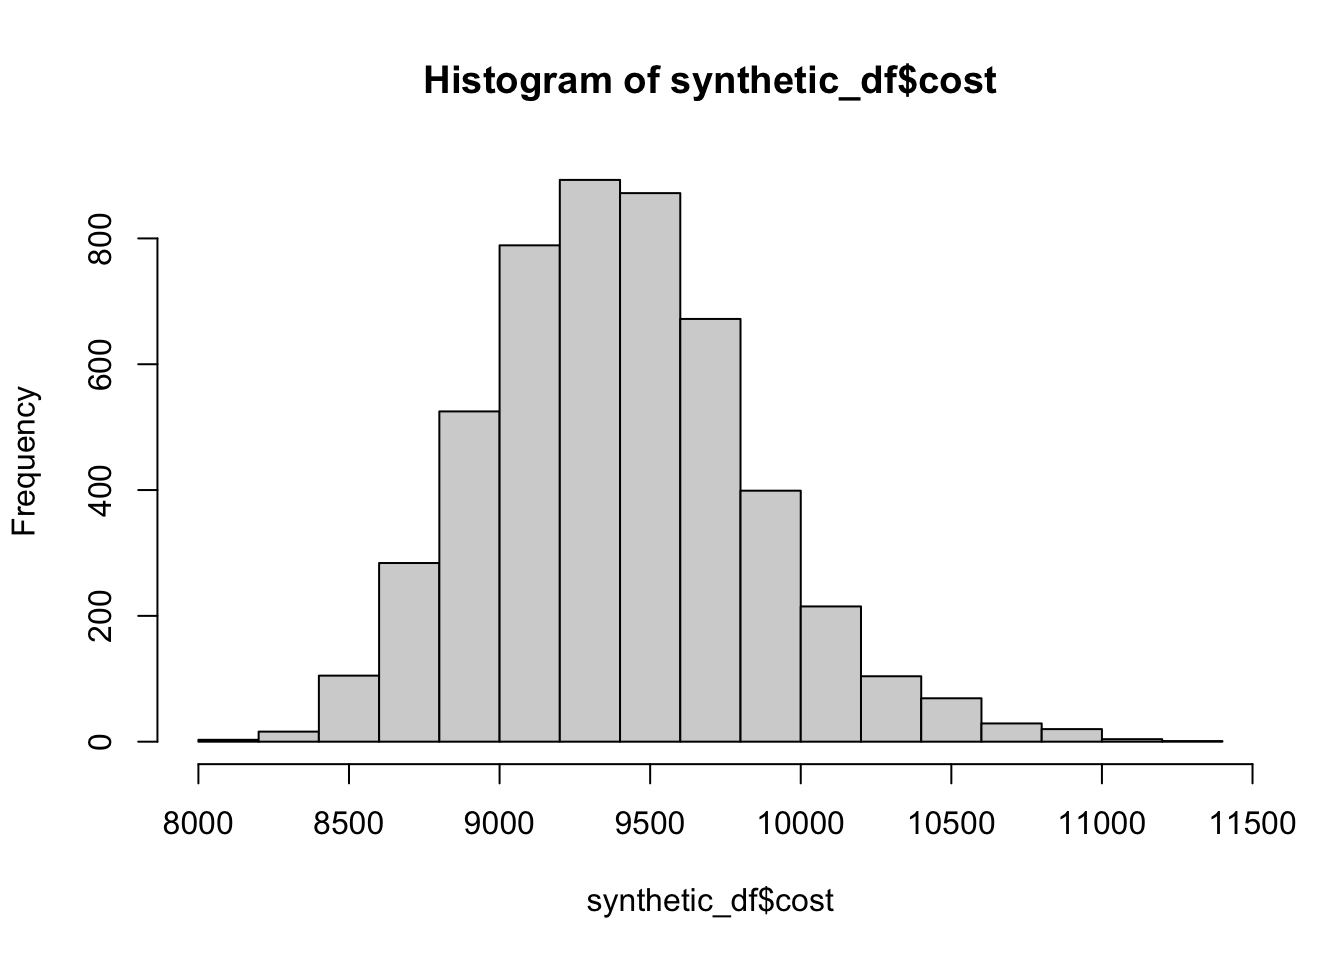

In [ ]:
# load dataset
synthetic_df <- read_csv(here("raw-data", "cohort.csv"))

### Study Population

The synthetic data consists of a 5,000 observations with no missing data. The dataset was evaluated in its entirety, with no exclusions based on outliers or key variables for a complete-case analysis. The final analysis included all 5,000 observations originally developed synthetically in the dataset.

### Study Variables and Outcome

Cardiac events may include any sudden, serious problem impacting the cardiovascular system, particularly the heart. All synthetic data were developed based on the data collection and observations in a national dataset of adult (18 years and older) cardiac hospitalizations in the United States from 2025. Based on the national dataset, cardiac events were pre-defined and measured in the dataset as a binary variable (e.g., yes or no if a cardiac event was observed in the patient) based on ICD-9 and ICD-10 codes coded by the care team or hospital. In this study, the dependent variable was cardiac events and was measured using the synthetic dataset’s pre-defined and measured reports as stated above. The primary independent variable in this study was medical costs. Based on the national dataset, medical costs were collected and measured in the dataset for each observation. Medical costs were calculated by the hospital billing team based on the type of care received given the particular cardiac event experienced by the patient at the point-of-care and time received. Potential confounders include sex, age, and gender. All potential confounders were self-reported by patients for hospital system record collections and are routinely collected during admission to hospital stays or to receive care.

Biological and behavioral health factors (sex, age, smoking) were selected a priori based on prior research and established causal diagrams in literature showing the association and influence of these factors on financial factors and cardiac events. All study variables were assessed in their original, individual item level. No variables were combined into composite indices, nor were any continuous variables transformed into categorical groupings. We assessed biases such as selection bias in the dependent, independent, and potential confounders using Pearson’s Chi-squared test and Wilcoxon rank sum test and visually assessed spread of potential confounders using histograms.

### Statistical Analysis

We used logistic regression (using R’s *stats* built-in package) to evaluate the odds ratios and 95% confidence intervals (CI) for the relationship between medical costs and cardiac events controlling for sex, age, and smoking. Reference groups for categorical variables sex and smoking include male and non-smoker, respectively. Logistic regression is a classification algorithm that models the log-odds of an event occurring by optimizing coefficients using maximum likelihood estimation. The logistic regression hypothesis is modeled by predictors $x$ and coefficients $\theta$: $$h_{\theta} = \frac{1}{1 + e^{-\theta^Tx}}$$

For this study, our logistic regression equation was modeled with cardiac event (yes or no) as the dependent variable and medical cost as the primary independent variable. To control for confounding, our model also adjusted for sex, age, and smoking. Specifically, let $Y$ represent a given outcome for an individual $i$:

$$Y_i = \alpha + \beta_1Cost_{1,i} + \beta_2Sex_{2,i} + \beta_3Smoke_{3,i} + \beta_4Age_{4,i}$$

$Cost$ is the indicator for medical cost related to the observed cardiac event, $Sex$ is an indicator for the self-reported sex (male or female) by the individual, $Smoke$ is the indicator for the self-reported smoking status of the patient when the data were collected, and $Age$ is the self-reported age of the patient. Each indicator is calculated for every individual $i$ in the dataset. All analyses were performed in RStudio (Version 2026.04.0+526).

## Results

### Population Demographics

Among the 5,000 individuals in our study, the majority of participants self-reported as non-smokers (N = 4,354, 87%), female (N = 2,866, 57%) and had an average age of 45 and average medical cost of \$9,376. In the overal study population, we observed an unequal balance in self-reported smoking, but a generally balanced self-report in sex (Table 1). Potential confounders smoke, sex, and cost were statistically significant with p \< 0.001. Age groups between those who experienced cardiac events and did not experience cardiac events were similar interquartile ranges and thus a p=0.11.

In [ ]:
# Make binary variables factors
synthetic_df$female <- factor(synthetic_df$female, levels=c(0,1), labels=c("Male", "Female"))
synthetic_df$smoke <- factor(synthetic_df$smoke, levels=c(0,1), labels=c("No Smoke", "Smoke"))
synthetic_df$cardiac <- factor(synthetic_df$cardiac, levels=c(0,1), labels=c("No Cardiac", "Cardiac"))

# Create table labels
label(synthetic_df$female) <- "Sex"
label(synthetic_df$smoke) <- "Smoke"
label(synthetic_df$cost) <- "Cost"
label(synthetic_df$age) <- "Age"

# create table 1
synthetic_df %>% 
  tbl_summary(by = cardiac) %>% 
  add_p() %>% 
  add_overall() %>% 
  bold_labels()

The study population was mostly imbalanced across those who did and did not experience cardiac events. For example, among individuals who did not experience a cardiac event 87% were non-smokers compared to 13%. Similarly, among individuals who did experience a cardiac event 88% were men and 12% were women. Individuals who experienced a cardiac event had an average medical cost of \$10,230 compared to an average medical cost of \$9,350 among individuals who did not experience a cardiac event. This resulted in an absolute difference of \$880 between the two groups, which depending on socioeconomic factors can be a significant difference. We also observed a steady positive trend in cost by age in individuals who experienced a cardiac event during our study period (Figure 1).

In [ ]:
# dataframe including only those with cardiac events
cardiac_df <- synthetic_df %>% 
  filter(cardiac == "Cardiac", smoke == "Smoke")

trend_plot <- ggplot(cardiac_df, aes(x = age, y = cost)) +
  geom_point(color = "darkblue", size = 2) +          
  geom_smooth(
    method = "loess",                                  
    se = FALSE,                                        
    color = "royalblue", 
    linewidth = 1
  ) +
  labs(x = "Age (Years)", y = "Medical Cost ($)") +
  theme (plot.caption = element_text(hjust = 0, face = "bold", size = 10))

# save line graph plot to working directory
ggsave("trend_plot.png")

Saving 5 x 3 in image
`geom_smooth()` using formula = 'y ~ x'

In [ ]:
# logistic regression analysis - crude model
# model: logistic regression
logistic_crude <- glm(cardiac ~ cost, data = synthetic_df, family = "binomial")
summary(logistic_crude)


Call:
glm(formula = cardiac ~ cost, family = "binomial", data = synthetic_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -5.242e+01  2.326e+00  -22.54   <2e-16 ***
cost         5.071e-03  2.324e-04   21.82   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 2129.8  on 4999  degrees of freedom
Residual deviance: 1178.6  on 4998  degrees of freedom
AIC: 1182.6

Number of Fisher Scoring iterations: 7


Call:
glm(formula = cardiac ~ cost + female + smoke + age, family = "binomial", 
    data = synthetic_df)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -9.472e+01  4.954e+00 -19.119   <2e-16 ***
cost          1.023e-02  5.442e-04  18.808   <2e-16 ***
femaleFemale  2.989e-01  2.615e-01   1.143    0.253    
smokeSmoke   -3.037e+00  3.094e-01  -9.815   <2e-16 ***
age          -1.637e-01  1.101e-02 -14.875   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 2129.82  on 4999  degrees of freedom
Residual deviance:  782.31  on 4995  degrees of freedom
AIC: 792.31

Number of Fisher Scoring iterations: 8

### Prevalence and Odds Ratios for Cardiac Event

In this study population, the overall prevalence of a cardiac event was 5.5% (N = 275). Of the individuals who did experience a cardiac event, 52% (N = 142) self-reported as ever smokers and 88% (N = 242) were male. The average age of those who experienced a cardiac event was 47 years and the average medical cost was \$10,230 (Table 1).

In [ ]:
# create table 2 separately for crude and adjusted models in order to later merge
table2_adjusted <- logistic_adjusted %>% 
  tbl_regression(exponentiate = TRUE) %>% 
  bold_p() %>% 
  add_global_p() %>% 
  italicize_levels()

table2_adjusted

In our adjusted logistic regression model, we observed a 1% increase in odds for a cardiac event (OR: 1.01, 95% CI: 1.01, 1.01) for every \$1 increase in cost (Table 2). Additionally, for two key confounders, we observed a significant finding in increased odds: individuals who self-reported having ever smoked had 95% lower odds of a cardiac event compared to non-smokers and each increase in year in age was associated with 15% lower odds of a cardiac event. Lastly, we observed a 35% increase in odds for a cardiac event in females compared to males, but the confidence interval included the null (Figure 2).

In [ ]:
coefs <- tidy(logistic_adjusted, exponentiate = TRUE, conf.int = TRUE)
coefs <- coefs[coefs$term != "(Intercept)", ]
coefs$term <- c("Cost", "Sex", "Smoke", "Age")

coefs$coef_ci <- sprintf(
  "%.2f (%.2f, %.2f)",
  coefs$estimate, coefs$conf.low, coefs$conf.high
)

# create and save forrest plot as .png
save_forrest("forrest_plot.png", function() {
  forrest(
  coefs,
  estimate = "estimate",
  lower = "conf.low",
  upper = "conf.high",
  label = "term",
  header = "Predictor",
  cols     = c("OR (95% CI)" = "coef_ci"),
  widths   = c(3, 4, 2.5),
  xlab     = "Odds Ratio (95% CI)",
  stripe   = TRUE,
  ref_line = 1
)
}, width = 5, height = 3, dpi = 300, bg = "white")

# include forest plot image into manuscript
knitr::include_graphics(here("forrest_plot.png"))

## Discussion

In this study, we found that cost is associated with an increase in odds for cardiac events. Biological and behavioral health factors were associated with the relationship of interest; specifically, sex and identifying as female were associated with increased odds in experiencing a cardiac event and smoking was associated with lower odds of experiencing a cardiac event. Our finding that smoking was associated with lower odds of cardiac events is counter to current literature which has strongly established a causal relationship in smoking increasing the risk for cardiac events. We believe that our findings that smoking is protective (OR = 0.05, CI = 0.03, 0.09) may be driven by the imbalance in smoking and rates of cardiac events in females compared to males who make up 88% of cardiac events in our study. Additionally, the contractual findings we observed compared to literature may also be driven by inherent differences in our synthetic dataset compared to real-world data from electronic health records or claims data. Moving forward, we will seek to perform this study on electronic health records to validate our findings in this study.

We also acknowledge that our study is not without limitations. First, this study used synthetic data that may not accurately reflect the true prevalence of the variables, nor characteristics of the study population. Future studies should seek to use non-synthetic data to validate these findings. Secondly, the prevalence of cardiac events in this study population was rare, which may have the potential to introduce statistical bias or generous significance levels. However, given the ability to interpret the odds ratio as risk ratio in rare outcomes, we pursued the use of logistic regression despite the 5.5% prevalence of cardiac events in our study population. Lastly, we observed extreme class imbalance between cardiac events in men and women, with men experiencing the majority of cardiac events.

In summary, our findings suggest an association between cost and cardiac events controlling for biological and behavioral health factors further adding evidence of the influence economic factors have on health, particularly cardiovascular diseases and hospitalizations.

## Generative AI Statement

All work, graphics/visuals, writing, study design, data analysis, and work to produce this manuscript was completed without the use of generative AI technology (e.g., ChatGPT).